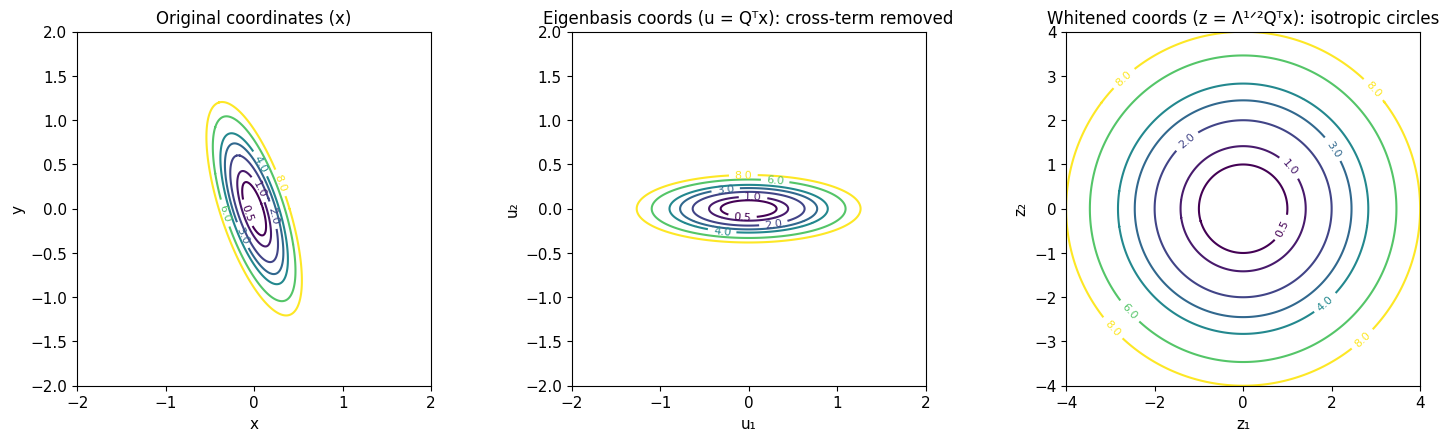

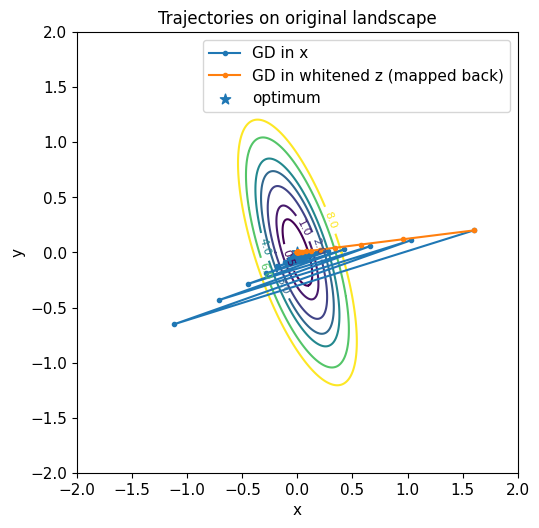

A (Hessian):
 [[100.  30.]
 [ 30.  20.]]
Eigenvalues: [ 10. 110.]
Eigenvectors Q (columns):
 [[ 0.31622777 -0.9486833 ]
 [-0.9486833  -0.31622777]]
Condition number κ(A) = λ_max/λ_min = 11.000000000000002


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1) Define quadratic f(x) = 1/2 x^T A x
# ----------------------------
A = np.array([[100.0, 30.0],
              [ 30.0, 20.0]])

def f_xy(X, Y):
    # Evaluate f on a grid (X,Y are meshgrid arrays)
    # f = 1/2 [x y] A [x; y]
    return 0.5 * (A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)

def grad(x):
    # gradient of 1/2 x^T A x is A x
    return A @ x

# ----------------------------
# 2) Eigendecomposition of Hessian: A = Q Λ Q^T
# ----------------------------
# For SPD A, eigh gives real eigenvalues and orthonormal eigenvectors.
lam, Q = np.linalg.eigh(A)         # lam sorted ascending, Q columns are eigenvectors
Lam = np.diag(lam)

# Rotation (eigenbasis change): u = Q^T x   <=> x = Q u
# Whitening / curvature normalization: z = Λ^{1/2} u = Λ^{1/2} Q^T x
sqrtLam = np.diag(np.sqrt(lam))
inv_sqrtLam = np.diag(1.0 / np.sqrt(lam))

def x_to_u(x):
    return Q.T @ x

def u_to_x(u):
    return Q @ u

def x_to_z(x):
    # z = sqrt(Λ) Q^T x
    return sqrtLam @ (Q.T @ x)

def z_to_x(z):
    # x = Q Λ^{-1/2} z
    return Q @ (inv_sqrtLam @ z)

def f_from_u(U, V):
    # In eigenbasis: f = 1/2 u^T Λ u = 1/2 (λ1 u1^2 + λ2 u2^2)
    return 0.5 * (lam[0]*U**2 + lam[1]*V**2)

def f_from_z(Z1, Z2):
    # In whitened coords: f = 1/2 z^T z = 1/2 (z1^2 + z2^2)
    return 0.5 * (Z1**2 + Z2**2)

# ----------------------------
# 3) Plot contours in x-space, u-space (rotated), and z-space (whitened)
# ----------------------------
def make_grid(lim=2.0, n=401):
    xs = np.linspace(-lim, lim, n)
    ys = np.linspace(-lim, lim, n)
    X, Y = np.meshgrid(xs, ys)
    return X, Y

# Choose limits large enough to see anisotropy
X, Y = make_grid(lim=2.0, n=401)
F = f_xy(X, Y)

# For u-space: create grid in u and compute f(u) directly (diagonal quadratic)
U, V = make_grid(lim=2.0, n=401)
F_u = f_from_u(U, V)

# For z-space: circles
Z1, Z2 = make_grid(lim=4.0, n=401)  # bigger lim because scaling changes
F_z = f_from_z(Z1, Z2)

# Levels: pick consistent function values
levels = np.array([0.5, 1, 2, 3, 4, 6, 8])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# x-space contours
cs0 = axes[0].contour(X, Y, F, levels=levels)
axes[0].clabel(cs0, inline=True, fontsize=8)
axes[0].set_title("Original coordinates (x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal", adjustable="box")

# u-space contours (rotated eigenbasis)
cs1 = axes[1].contour(U, V, F_u, levels=levels)
axes[1].clabel(cs1, inline=True, fontsize=8)
axes[1].set_title("Eigenbasis coords (u = Qᵀx): cross-term removed")
axes[1].set_xlabel("u₁")
axes[1].set_ylabel("u₂")
axes[1].set_aspect("equal", adjustable="box")

# z-space contours (whitened)
# Need levels that fit in this z-grid; levels correspond to radii sqrt(2*level)
levels_z = levels
cs2 = axes[2].contour(Z1, Z2, F_z, levels=levels_z)
axes[2].clabel(cs2, inline=True, fontsize=8)
axes[2].set_title("Whitened coords (z = Λ¹ᐟ²Qᵀx): isotropic circles")
axes[2].set_xlabel("z₁")
axes[2].set_ylabel("z₂")
axes[2].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

# ----------------------------
# 4) Demonstrate gradient descent trajectories
# ----------------------------
def gd_x(x0, eta, steps):
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(steps):
        x = x - eta * grad(x)
        traj.append(x.copy())
    return np.array(traj)

def gd_z_then_map_back(x0, eta, steps):
    """
    Run GD in whitened coords z on g(z) = 1/2 ||z||^2,
    then map points back to x. This corresponds to
    preconditioned GD / Newton-like scaling in x.
    """
    z = x_to_z(x0)
    traj_x = [z_to_x(z).copy()]
    for _ in range(steps):
        # grad of 1/2 ||z||^2 is z
        z = z - eta * z
        traj_x.append(z_to_x(z).copy())
    return np.array(traj_x)

# Pick a start point not aligned with eigenvectors to show the effect
x0 = np.array([1.6, 0.2])

# Stable step size for x-space GD: eta < 2 / lambda_max
lambda_max = lam.max()
eta_x = 1.8 / lambda_max     # conservative
eta_z = 0.4                  # any eta_z in (0,2) is stable for 1/2||z||^2

steps = 25
traj_plain = gd_x(x0, eta_x, steps)
traj_white = gd_z_then_map_back(x0, eta_z, steps)

# Plot both trajectories over original contours
fig, ax = plt.subplots(1, 1, figsize=(5.5, 5.5))
cs = ax.contour(X, Y, F, levels=levels)
ax.clabel(cs, inline=True, fontsize=8)

ax.plot(traj_plain[:,0], traj_plain[:,1], marker="o", ms=3, label="GD in x")
ax.plot(traj_white[:,0], traj_white[:,1], marker="o", ms=3, label="GD in whitened z (mapped back)")

ax.scatter([0], [0], s=60, marker="*", label="optimum")
ax.set_title("Trajectories on original landscape")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 5) Print key quantities for sanity
# ----------------------------
print("A (Hessian):\n", A)
print("Eigenvalues:", lam)
print("Eigenvectors Q (columns):\n", Q)
print("Condition number κ(A) = λ_max/λ_min =", lam.max()/lam.min())


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ----------------------------
# Quadratic definition
# f(x) = 1/2 x^T A x
# ----------------------------
A = np.array([[10.0, -4.0],
              [-4.0, 10.0]])  # corresponds to f(x,y)=5x^2 - 4xy + 5y^2

def f_grid(X, Y):
    return 0.5 * (A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)

def grad(x):
    return A @ x

# Eigendecomposition A = Q Λ Q^T
lam, Q = np.linalg.eigh(A)
Lam = np.diag(lam)
sqrtLam = np.diag(np.sqrt(lam))
inv_sqrtLam = np.diag(1.0 / np.sqrt(lam))

def x_to_z(x):
    # z = Λ^{1/2} Q^T x
    return sqrtLam @ (Q.T @ x)

def z_to_x(z):
    # x = Q Λ^{-1/2} z
    return Q @ (inv_sqrtLam @ z)

# ----------------------------
# Trajectory generators
# ----------------------------
def run_gd(x0, eta, steps):
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(steps):
        x = x - eta * grad(x)
        traj.append(x.copy())
    return np.array(traj)

def run_newton(x0, eta, steps):
    # Newton step: x <- x - eta * A^{-1} grad(x)
    # For this quadratic, grad(x)=A x, so A^{-1}grad(x)=x, so x <- (1-eta) x
    # We'll compute it generally anyway.
    Ainv = np.linalg.inv(A)
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(steps):
        x = x - eta * (Ainv @ grad(x))
        traj.append(x.copy())
    return np.array(traj)

def run_whitened_gd_mapped_back(x0, eta, steps):
    # Run GD on g(z) = 1/2 ||z||^2, then map back to x
    z = x_to_z(x0)
    traj = [z_to_x(z).copy()]
    for _ in range(steps):
        z = z - eta * z  # grad of 1/2||z||^2 is z
        traj.append(z_to_x(z).copy())
    return np.array(traj)

# ----------------------------
# Plot helpers
# ----------------------------
def make_contour(ax, lim=2.2, n=401, levels=None):
    xs = np.linspace(-lim, lim, n)
    ys = np.linspace(-lim, lim, n)
    X, Y = np.meshgrid(xs, ys)
    F = f_grid(X, Y)
    if levels is None:
        levels = np.array([0.5, 1, 2, 3, 4, 6, 8])
    cs = ax.contour(X, Y, F, levels=levels)
    ax.clabel(cs, inline=True, fontsize=8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return X, Y, F

# ----------------------------
# Configure experiments
# ----------------------------
x0 = np.array([1.6, 0.2])
steps = 30

# GD stable if eta < 2 / lambda_max
eta_gd = 1.8 / lam.max()    # conservative
eta_newton = 0.6            # any eta in (0,2) stable for quadratic (linear contraction)
eta_white = 0.6             # in z-space (same stability condition)

traj_gd = run_gd(x0, eta_gd, steps)
traj_newton = run_newton(x0, eta_newton, steps)
traj_white = run_whitened_gd_mapped_back(x0, eta_white, steps)

# ----------------------------
# A) Iterative static plots (one image per step)
# ----------------------------
def save_frames(prefix="frame", every=1):
    fig, ax = plt.subplots(figsize=(6, 6))
    make_contour(ax, lim=2.2)
    ax.set_title("Optimization trajectories (incremental)")

    # Pre-create line objects for speed/clarity
    ln_gd, = ax.plot([], [], marker="o", ms=3, label="GD (x)")
    ln_newton, = ax.plot([], [], marker="o", ms=3, label="Newton (x)")
    ln_white, = ax.plot([], [], marker="o", ms=3, label="GD in whitened z (mapped back)")
    ax.scatter([0], [0], s=70, marker="*", label="optimum")
    ax.legend(loc="upper right")

    for k in range(0, steps + 1, every):
        ln_gd.set_data(traj_gd[:k+1, 0], traj_gd[:k+1, 1])
        ln_newton.set_data(traj_newton[:k+1, 0], traj_newton[:k+1, 1])
        ln_white.set_data(traj_white[:k+1, 0], traj_white[:k+1, 1])
        ax.set_title(f"Step {k}/{steps}")

        fig.savefig(f"{prefix}_{k:03d}.png", dpi=150)

    plt.close(fig)

# Uncomment to generate frames:
# save_frames(prefix="opt", every=1)

# ----------------------------
# B) Animation (GIF)
# ----------------------------
def animate(save_path="optimization.gif", fps=10):
    fig, ax = plt.subplots(figsize=(6, 6))
    make_contour(ax, lim=2.2)
    ax.scatter([0], [0], s=70, marker="*")

    ln_gd, = ax.plot([], [], marker="o", ms=3, label="GD (x)")
    ln_newton, = ax.plot([], [], marker="o", ms=3, label="Newton (x)")
    ln_white, = ax.plot([], [], marker="o", ms=3, label="Whitened GD (mapped back)")
    ax.legend(loc="upper right")

    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)

    def init():
        ln_gd.set_data([], [])
        ln_newton.set_data([], [])
        ln_white.set_data([], [])
        ax.set_title("Step 0")
        return ln_gd, ln_newton, ln_white

    def update(k):
        ln_gd.set_data(traj_gd[:k+1, 0], traj_gd[:k+1, 1])
        ln_newton.set_data(traj_newton[:k+1, 0], traj_newton[:k+1, 1])
        ln_white.set_data(traj_white[:k+1, 0], traj_white[:k+1, 1])
        ax.set_title(f"Step {k}/{steps}")
        return ln_gd, ln_newton, ln_white

    anim = FuncAnimation(fig, update, frames=range(steps+1),
                         init_func=init, blit=True, interval=1000//fps)

    # Save as GIF
    anim.save(save_path, writer=PillowWriter(fps=fps))
    plt.close(fig)

# Uncomment to save a GIF:
animate(save_path="optimization_1.gif", fps=12)

print("Eigenvalues:", lam)
print("Condition number:", lam.max() / lam.min())
print("eta_gd:", eta_gd, "eta_newton:", eta_newton, "eta_white:", eta_white)


Eigenvalues: [ 6. 14.]
Condition number: 2.3333333333333335
eta_gd: 0.1285714285714286 eta_newton: 0.6 eta_white: 0.6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ----------------------------
# Quadratic definition
# f(x) = 1/2 x^T A x
# ----------------------------
A = np.array([[100.0, 30.0],
              [ 30.0,  1.0]])

def f_grid(X, Y):
    return 0.5 * (A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)

def grad(x):
    return A @ x

# Eigendecomposition A = Q Λ Q^T
lam, Q = np.linalg.eigh(A)
Lam = np.diag(lam)
sqrtLam = np.diag(np.sqrt(lam))
inv_sqrtLam = np.diag(1.0 / np.sqrt(lam))

def x_to_z(x):
    # z = Λ^{1/2} Q^T x
    return sqrtLam @ (Q.T @ x)

def z_to_x(z):
    # x = Q Λ^{-1/2} z
    return Q @ (inv_sqrtLam @ z)

# ----------------------------
# Trajectory generators
# ----------------------------
def run_gd(x0, eta, steps):
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(steps):
        x = x - eta * grad(x)
        traj.append(x.copy())
    return np.array(traj)

def run_newton(x0, eta, steps):
    # Newton step: x <- x - eta * A^{-1} grad(x)
    # For this quadratic, grad(x)=A x, so A^{-1}grad(x)=x, so x <- (1-eta) x
    # We'll compute it generally anyway.
    Ainv = np.linalg.inv(A)
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(steps):
        x = x - eta * (Ainv @ grad(x))
        traj.append(x.copy())
    return np.array(traj)

def run_whitened_gd_mapped_back(x0, eta, steps):
    # Run GD on g(z) = 1/2 ||z||^2, then map back to x
    z = x_to_z(x0)
    traj = [z_to_x(z).copy()]
    for _ in range(steps):
        z = z - eta * z  # grad of 1/2||z||^2 is z
        traj.append(z_to_x(z).copy())
    return np.array(traj)

# ----------------------------
# Plot helpers
# ----------------------------
def make_contour(ax, lim=2.2, n=401, levels=None):
    xs = np.linspace(-lim, lim, n)
    ys = np.linspace(-lim, lim, n)
    X, Y = np.meshgrid(xs, ys)
    F = f_grid(X, Y)
    if levels is None:
        levels = np.array([0.5, 1, 2, 3, 4, 6, 8])
    cs = ax.contour(X, Y, F, levels=levels)
    ax.clabel(cs, inline=True, fontsize=8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return X, Y, F

# ----------------------------
# Configure experiments
# ----------------------------
x0 = np.array([1.6, 0.2])
steps = 30

# GD stable if eta < 2 / lambda_max
eta_gd = 1.8 / lam.max()    # conservative
eta_newton = 0.6            # any eta in (0,2) stable for quadratic (linear contraction)
eta_white = 0.6             # in z-space (same stability condition)

traj_gd = run_gd(x0, eta_gd, steps)
traj_newton = run_newton(x0, eta_newton, steps)
traj_white = run_whitened_gd_mapped_back(x0, eta_white, steps)

# ----------------------------
# A) Iterative static plots (one image per step)
# ----------------------------
def save_frames(prefix="frame", every=1):
    fig, ax = plt.subplots(figsize=(6, 6))
    make_contour(ax, lim=2.2)
    ax.set_title("Optimization trajectories (incremental)")

    # Pre-create line objects for speed/clarity
    ln_gd, = ax.plot([], [], marker="o", ms=3, label="GD (x)")
    ln_newton, = ax.plot([], [], marker="o", ms=3, label="Newton (x)")
    ln_white, = ax.plot([], [], marker="o", ms=3, label="GD in whitened z (mapped back)")
    ax.scatter([0], [0], s=70, marker="*", label="optimum")
    ax.legend(loc="upper right")

    for k in range(0, steps + 1, every):
        ln_gd.set_data(traj_gd[:k+1, 0], traj_gd[:k+1, 1])
        ln_newton.set_data(traj_newton[:k+1, 0], traj_newton[:k+1, 1])
        ln_white.set_data(traj_white[:k+1, 0], traj_white[:k+1, 1])
        ax.set_title(f"Step {k}/{steps}")

        fig.savefig(f"{prefix}_{k:03d}.png", dpi=150)

    plt.close(fig)

# Uncomment to generate frames:
# save_frames(prefix="opt", every=1)

# ----------------------------
# B) Animation (GIF)
# ----------------------------
def animate(save_path="optimization.gif", fps=10):
    fig, ax = plt.subplots(figsize=(6, 6))
    make_contour(ax, lim=2.2)
    ax.scatter([0], [0], s=70, marker="*")

    ln_gd, = ax.plot([], [], marker="o", ms=3, label="GD (x)")
    ln_newton, = ax.plot([], [], marker="o", ms=3, label="Newton (x)")
    ln_white, = ax.plot([], [], marker="o", ms=3, label="Whitened GD (mapped back)")
    ax.legend(loc="upper right")

    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)

    def init():
        ln_gd.set_data([], [])
        ln_newton.set_data([], [])
        ln_white.set_data([], [])
        ax.set_title("Step 0")
        return ln_gd, ln_newton, ln_white

    def update(k):
        ln_gd.set_data(traj_gd[:k+1, 0], traj_gd[:k+1, 1])
        ln_newton.set_data(traj_newton[:k+1, 0], traj_newton[:k+1, 1])
        ln_white.set_data(traj_white[:k+1, 0], traj_white[:k+1, 1])
        ax.set_title(f"Step {k}/{steps}")
        return ln_gd, ln_newton, ln_white

    anim = FuncAnimation(fig, update, frames=range(steps+1),
                         init_func=init, blit=True, interval=1000//fps)

    # Save as GIF
    anim.save(save_path, writer=PillowWriter(fps=fps))
    plt.close(fig)

# Uncomment to save a GIF:
animate(save_path="optimization_2.gif", fps=12)

print("Eigenvalues:", lam)
print("Condition number:", lam.max() / lam.min())
print("eta_gd:", eta_gd, "eta_newton:", eta_newton, "eta_white:", eta_white)


/tmp/ipython-input-3703444163.py:21: RuntimeWarning: invalid value encountered in sqrt
  sqrtLam = np.diag(np.sqrt(lam))
/tmp/ipython-input-3703444163.py:22: RuntimeWarning: invalid value encountered in sqrt
  inv_sqrtLam = np.diag(1.0 / np.sqrt(lam))


Eigenvalues: [ -7.38134414 108.38134414]
Condition number: -14.683144698271432
eta_gd: 0.01660802432562948 eta_newton: 0.6 eta_white: 0.6


In [ ]:
def quadratic_latex_from_A(A, var=("x", "y"), name="f", tol=1e-12, decimals=3):
    """
    Build LaTeX for f(x,y) = 1/2 [x y] A [x; y] expanded as:
        f(x,y) = (1/2)A11 x^2 + A12 x y + (1/2)A22 y^2
    Assumes A is 2x2; symmetrizes it to be safe.
    """
    A = np.asarray(A, dtype=float)
    if A.shape != (2, 2):
        raise ValueError("quadratic_latex_from_A expects a 2x2 matrix A.")

    # Symmetrize for numerical stability / user convenience
    A = 0.5 * (A + A.T)

    x, y = var
    a11, a12, a22 = A[0, 0], A[0, 1], A[1, 1]

    # Coefficients in expanded form for f(x,y) = 1/2 x^T A x
    c_x2 = 0.5 * a11
    c_xy = a12
    c_y2 = 0.5 * a22

    def fmt(c):
        # format coefficient with rounding; avoid "-0"
        c = 0.0 if abs(c) < tol else c
        s = f"{c:.{decimals}f}"
        if "." in s:
            s = s.rstrip("0").rstrip(".")
        if s == "-0":
            s = "0"
        return s

    def term(c, mono, first=False):
        if abs(c) < tol:
            return ""
        sign = "-" if c < 0 else "+"
        mag = abs(c)
        mag_s = fmt(mag)

        # Drop coefficient "1" for non-constant monomials
        if abs(mag - 1.0) < tol:
            coeff_part = ""
        else:
            coeff_part = mag_s

        body = f"{coeff_part}{mono}" if coeff_part else f"{mono}"

        if first:
            # first term: no leading '+', keep '-' if negative
            return f"-{body}" if c < 0 else f"{body}"
        else:
            return f" {sign} {body}"

    parts = []
    parts.append(term(c_x2, rf"{x}^2", first=True))
    parts.append(term(c_xy, rf"{x}{y}", first=(len("".join(parts)) == 0)))
    parts.append(term(c_y2, rf"{y}^2", first=(len("".join(parts)) == 0)))

    expr = "".join([p for p in parts if p != ""])
    if expr.strip() == "":
        expr = "0"

    return rf"${name}({x},{y}) = {expr}$"


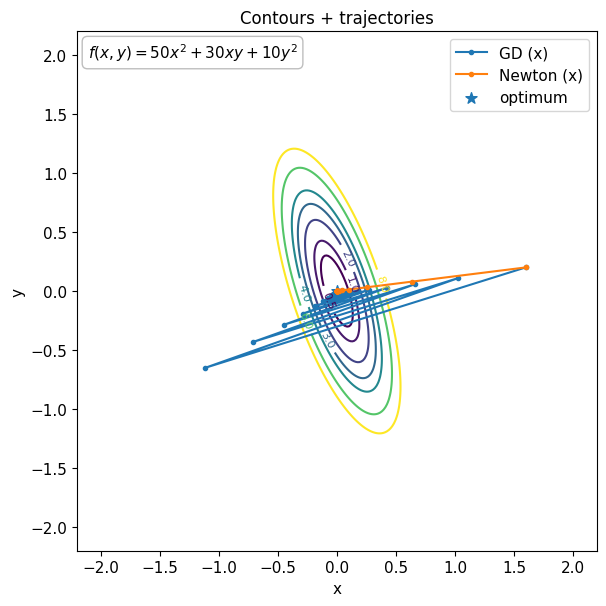

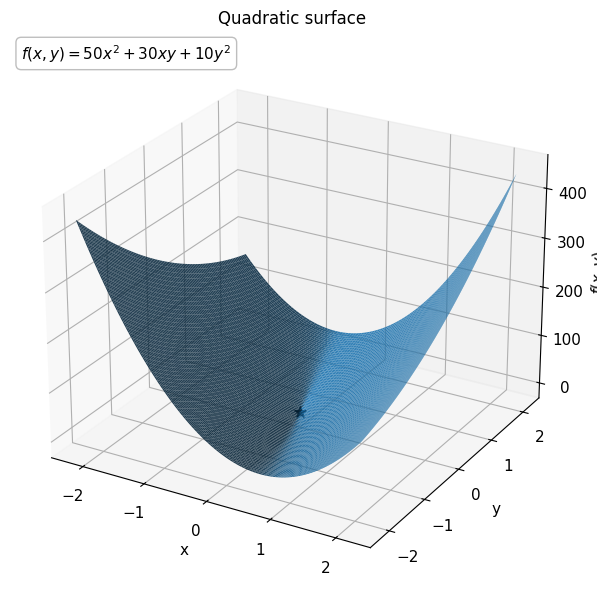

Saved: optimization_with_white.gif
Eigenvalues: [ 10. 110.]
Condition number: 11.000000000000002


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

# ----------------------------
# Matplotlib LaTeX-ish settings (uses mathtext; no external LaTeX needed)
# ----------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

A = np.array([[100.0, 30.0],
              [ 30.0, 20.0]])

def f_scalar(xy):
    x, y = float(xy[0]), float(xy[1])
    return 0.5 * (A[0,0]*x*x + 2*A[0,1]*x*y + A[1,1]*y*y)

def f_grid(X, Y):
    return 0.5 * (A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)

def grad(xy):
    return A @ xy

# Eigendecomposition (for whitening / preconditioning demos)
lam, Q = np.linalg.eigh(A)
sqrtLam = np.diag(np.sqrt(lam))
inv_sqrtLam = np.diag(1.0 / np.sqrt(lam))

def x_to_z(x):
    return sqrtLam @ (Q.T @ x)

def z_to_x(z):
    return Q @ (inv_sqrtLam @ z)

# ----------------------------
# Trajectories
# ----------------------------
def run_gd(x0, eta, steps):
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(steps):
        x = x - eta * grad(x)
        traj.append(x.copy())
    return np.array(traj)

def run_newton(x0, eta, steps):
    Ainv = np.linalg.inv(A)
    x = x0.copy()
    traj = [x.copy()]
    for _ in range(steps):
        x = x - eta * (Ainv @ grad(x))
        traj.append(x.copy())
    return np.array(traj)

def run_whitened_gd_mapped_back(x0, eta, steps):
    z = x_to_z(x0)
    traj = [z_to_x(z).copy()]
    for _ in range(steps):
        z = z - eta * z  # grad of 1/2||z||^2 is z
        traj.append(z_to_x(z).copy())
    return np.array(traj)

def run_gd_momentum(x0, eta, beta, steps):
    """
    Heavy-ball momentum:
        v_{k+1} = beta v_k - eta * grad(x_k)
        x_{k+1} = x_k + v_{k+1}
    """
    x = x0.copy()
    v = np.zeros_like(x)
    traj = [x.copy()]

    for _ in range(steps):
        v = beta * v - eta * grad(x)
        x = x + v
        traj.append(x.copy())

    return np.array(traj)

# ----------------------------
# Pretty LaTeX labels for the quadratic
# ----------------------------
# mathtext supports \begin{pmatrix} ... \end{pmatrix} and superscripts, etc.
eqn_text = quadratic_latex_from_A(A, decimals=3)
# ----------------------------
# Grid for plotting
# ----------------------------
def make_grid(lim=2.2, n=301):
    xs = np.linspace(-lim, lim, n)
    ys = np.linspace(-lim, lim, n)
    X, Y = np.meshgrid(xs, ys)
    return X, Y

X, Y = make_grid(lim=2.2, n=301)
F = f_grid(X, Y)

levels = np.array([0.5, 1, 2, 3, 4, 6, 8])

# ----------------------------
# Experiment config
# ----------------------------
x0 = np.array([1.6, 0.2])
steps = 30

eta_gd = 1.8 / lam.max()   # stable for GD in x if < 2/lambda_max
eta_newton = 0.6
eta_white = 0.6

traj_gd = run_gd(x0, eta_gd, steps)
traj_newton = run_newton(x0, eta_newton, steps)
traj_white = run_whitened_gd_mapped_back(x0, eta_white, steps)
traj_momentum = run_gd_momentum(x0, eta=0.01, beta=0.9, steps=steps)

# ============================================================
# 1) 2D contour plot with LaTeX equation rendered
# ============================================================
fig2d, ax2d = plt.subplots(figsize=(6.2, 6.2))
cs = ax2d.contour(X, Y, F, levels=levels)
ax2d.clabel(cs, inline=True, fontsize=8)

ax2d.plot(traj_gd[:,0], traj_gd[:,1], marker="o", ms=3, label="GD (x)")
ax2d.plot(traj_newton[:,0], traj_newton[:,1], marker="o", ms=3, label="Newton (x)")
# ax2d.plot(traj_white[:,0], traj_white[:,1], marker="o", ms=3, label="Whitened GD (mapped back)")
# ax2d.plot(traj_momentum[:, 0], traj_momentum[:,1], marker="o", ms=3, label="GD + Momentum")
ax2d.scatter([0], [0], s=70, marker="*", label="optimum")

ax2d.set_aspect("equal", adjustable="box")
ax2d.set_xlabel("x")
ax2d.set_ylabel("y")
ax2d.set_title("Contours + trajectories")

# Put the equation in a semi-transparent text box in axes coordinates
ax2d.text(
    0.02, 0.98, eqn_text,
    transform=ax2d.transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor="0.7")
)

ax2d.legend(loc="upper right")
plt.tight_layout()
plt.show()

# ============================================================
# 3D surface plot ONLY (no trajectories)
# ============================================================
fig3d = plt.figure(figsize=(7.2, 6.2))
ax3d = fig3d.add_subplot(111, projection="3d")

# Surface
ax3d.plot_surface(
    X, Y, F,
    rstride=3, cstride=3,
    linewidth=0,
    antialiased=True,
    alpha=0.9
)

# Optional: mark the optimum
ax3d.scatter([0], [0], [0], s=70, marker="*", color="k")

ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel(r"$f(x,y)$")
ax3d.set_title("Quadratic surface")

# Render the scalar quadratic equation (auto-generated from A)
ax3d.text2D(
    0.02, 0.98, quadratic_latex_from_A(A),
    transform=ax3d.transAxes,
    va="top", ha="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.85,
        edgecolor="0.7"
    )
)

# Nice viewing angle
ax3d.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.show()


# ============================================================
# 3) Optional: Animated 2D contour trajectory with equation
# ============================================================
def animate_2d(save_path="optimization.gif", fps=12):
    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    cs = ax.contour(X, Y, F, levels=levels)
    ax.clabel(cs, inline=True, fontsize=8)

    # Equation box
    ax.text(
        0.02, 0.98, eqn_text,
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

    ax.scatter([0], [0], s=70, marker="*")

    ln_gd, = ax.plot([], [], marker="o", ms=3, label="GD (x)")
    ln_newton, = ax.plot([], [], marker="o", ms=3, label="Newton (x)")
    # ln_white, = ax.plot([], [], marker="o", ms=3, label="Whitened GD (mapped back)")
    ax.legend(loc="upper right")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    def init():
        ln_gd.set_data([], [])
        ln_newton.set_data([], [])
        # ln_white.set_data([], [])
        ax.set_title("Step 0")
        return (ln_gd,ln_newton)#, ln_newton, ln_white

    def update(k):
        ln_gd.set_data(traj_gd[:k+1, 0], traj_gd[:k+1, 1])
        ln_newton.set_data(traj_newton[:k+1, 0], traj_newton[:k+1, 1])
        # ln_white.set_data(traj_white[:k+1, 0], traj_white[:k+1, 1])
        ax.set_title(f"Step {k}/{steps}")
        return (ln_gd,ln_newton)#, ln_newton, ln_white

    anim = FuncAnimation(fig, update, frames=range(steps + 1),
                         init_func=init, blit=True, interval=1000 // fps)
    anim.save(save_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"Saved: {save_path}")

# Uncomment to save a GIF:
animate_2d(save_path="optimization_with_newton.gif", fps=2)

print("Eigenvalues:", lam)
print("Condition number:", lam.max() / lam.min())